<a href="https://colab.research.google.com/github/AKBER-HUSSAIN/DL-2026/blob/main/dl_week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2

1.Implement AND and OR logic operations using a single perceptron, and verify the correctness of the output using appropriate truth tables. (linear Data)


In [ ]:
def step(x):
    return 1 if x >= 0 else 0

class Perceptron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def predict(self, inputs):
        total = np.dot(self.weights, inputs) + self.bias
        return step(total)

weights = np.array([1, 1])
bias = -1.5

and_gate = Perceptron(weights, bias)


print("AND Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", and_gate.predict(np.array(x)))

AND Gate
(0, 0) -> 0
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


In [ ]:
def step(x):
    return 1 if x >= 0 else 0

class Perceptron:
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def predict(self, inputs):
        total = np.dot(self.weights, inputs) + self.bias
        return step(total)


weights = np.array([1, 1])
bias = -0.5

or_gate = Perceptron(weights, bias)


print("OR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", or_gate.predict(np.array(x)))

OR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 1



3. Implement the XOR and (¬XOR) logic operation using a multi-perceptron network, and analyze how multiple perceptrons overcome the limitations of a single perceptron.


In [ ]:
# A XOR B = (A OR B) AND (A NAND B)
class XOR:
    def __init__(self):

        self.n1 = Perceptron([1, 1], -0.5)

        self.n2 = Perceptron([-1, -1], 1.5)

        self.n3 = Perceptron([1, 1], -1.5)
    def predict(self, inputs):
        h1 = self.n1.predict(inputs)
        h2 = self.n2.predict(inputs)
        o1 = self.n3.predict([h1, h2])

        return o1

xor_gate = XOR()

print("XOR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", xor_gate.predict(np.array(x)))

XOR Gate
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 0


In [ ]:
# XNOR = (A AND B) OR (A NOR B)
class XNOR:
    def __init__(self):
        # A AND B
        self.n1 = Perceptron([1, 1], -1.5)
        # A NOR B
        self.n2 = Perceptron([-1, -1], 0.5)
        # (A AND B) OR (A NOR B)
        self.n3 = Perceptron([1, 1], -0.5)
    def predict(self, inputs):
        h1 = self.n1.predict(inputs)
        h2 = self.n2.predict(inputs)
        o1 = self.n3.predict([h1, h2])

        return o1

xnor_gate = XNOR()

print("XNOR Gate")
for x in [(0,0), (0,1), (1,0), (1,1)]:
    print(x, "->", xnor_gate.predict(np.array(x)))

XNOR Gate
(0, 0) -> 1
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


4. Demonstrate that the thresholding logic used by perceptron is very harsh.

In [ ]:
harsh = Perceptron([1], -1)

for x in [(0.9999,), (1.00001,)]:
    print(x, "->", harsh.predict(np.array(x)))

(0.9999,) -> 0
(1.00001,) -> 1


5. Implement the Perceptron Learning Algorithm and study the effect of weight updates on convergence for a binary decision problem such as determining whether a user would like to watch a movie.
Note: Consider a small dataset(design your own excel csv sheet) of movie records with Boolean or real-valued features, for example:
 f1​: Is actor Matt Damon present
 f2​: Is the genre Thriller
 f3​: Is the director Christopher Nolan
 f4: IMDb rating (scaled between 0 and 1)
The output label represents like (1) or dislike (0). Train the perceptron model using these features and observe how weight updates influence convergence and classification performance.
Test with a sample record to show whether a perceptron properly classifies it or not.
i) Check with MP Perceptron  (without weights and bias)
ii) Check with Perceptron (with weights)
iii) Check with Perceptron (with weights and bias)


In [ ]:
# creating dataset
data = {
    'f1': [1, 0, 0, 1, 1],
    'f2': [1, 0, 1, 0, 1],
    'f3': [0, 1, 0, 1, 1],
    'f4': [9.4, 8.2, 8.1, 9.0, 7.2],
    'label': [1, 0, 0, 1, 1],
}

movie_df = pd.DataFrame(data)
movie_df

,f1,f2,f3,f4,label
0,1,1,0,9.4,1
1,0,0,1,8.2,0
2,0,1,0,8.1,0
3,1,0,1,9.0,1
4,1,1,1,7.2,1


In [ ]:
x = movie_df.drop('label', axis=1)
y = movie_df['label']

In [ ]:
# i) Check with MP Perceptron (without weights and bias)
def step(x):
    return 1 if x >= 0 else 0

class MP_Perceptron:
    def predict(self, inputs):
        total = np.sum(inputs)
        return step(total)

mp = MP_Perceptron()
for i in range(len(movie_df)):
    print(f"actual - {y.iloc[i]} predicted - {mp.predict(x.iloc[i])}")

actual - 1 predicted - 1
actual - 0 predicted - 1
actual - 0 predicted - 1
actual - 1 predicted - 1
actual - 1 predicted - 1


In [ ]:
# ii) Check with Perceptron (with weights)
class Perceptron_weights:
    def __init__(self, epochs, lr):
        self.epochs = epochs
        self.lr = lr
    def fit(self, x, y):
        self.weights = np.zeros(x.shape[1])
        for _ in range(self.epochs):
            total_errors = 0
            for i in range(len(x)):
                z = np.dot(self.weights, x.iloc[i])
                y_pred = self.predict(x.iloc[i])
                error = y[i] - y_pred
                if error != 0:
                    total_errors += 1
                self.weights += self.lr * error * x.iloc[i]
            print(f"Epoch {_+1} | Total misclassifications: {total_errors}")

            if total_errors == 0:
                break

    def predict(self, inputs):
        total = np.dot(self.weights, inputs)
        return step(total)

percep_weights = Perceptron_weights(20, 0.1)
percep_weights.fit(x, y)

print("final weights:", percep_weights.weights)

for i in range(len(movie_df)):
    print(f"actual - {y.iloc[i]} predicted - {percep_weights.predict(x.iloc[i])}")

Epoch 1 | Total misclassifications: 2
Epoch 2 | Total misclassifications: 2
Epoch 3 | Total misclassifications: 2
Epoch 4 | Total misclassifications: 2
Epoch 5 | Total misclassifications: 2
Epoch 6 | Total misclassifications: 2
Epoch 7 | Total misclassifications: 2
Epoch 8 | Total misclassifications: 2
Epoch 9 | Total misclassifications: 2
Epoch 10 | Total misclassifications: 2
Epoch 11 | Total misclassifications: 1
Epoch 12 | Total misclassifications: 0
final weights: f1    1.00
f2    0.00
f3   -0.10
f4   -0.02
Name: 0, dtype: float64
actual - 1 predicted - 1
actual - 0 predicted - 0
actual - 0 predicted - 0
actual - 1 predicted - 1
actual - 1 predicted - 1


In [ ]:
# iii) Check with Perceptron (with weights and bias)
class Perceptron:
    def __init__(self, epochs, lr):
        self.epochs = epochs
        self.lr = lr
    def fit(self, x, y):
        self.weights = np.zeros(x.shape[1])
        self.bias = 0
        for _ in range(self.epochs):
            total_errors = 0
            for i in range(len(x)):
                z = np.dot(self.weights, x.iloc[i]) + self.bias
                y_pred = self.predict(x.iloc[i])
                error = y[i] - y_pred
                if error != 0:
                    total_errors += 1
                self.weights += self.lr * error * x.iloc[i]
                self.bias += self.lr * error
            print(f"Epoch {_+1} | Total misclassifications: {total_errors}")

            if total_errors == 0:
                break
    def predict(self, inputs):
        total = np.dot(self.weights, inputs) + self.bias
        return step(total)

percep = Perceptron(20, 0.1)
percep.fit(x, y)
print("===========================================")
print("final weights:", percep.weights)
print("final bias:", percep.bias)
print("===========================================")

for i in range(len(movie_df)):
    print(f"actual - {y.iloc[i]} predicted - {percep.predict(x.iloc[i])}")

Epoch 1 | Total misclassifications: 2
Epoch 2 | Total misclassifications: 2
Epoch 3 | Total misclassifications: 2
Epoch 4 | Total misclassifications: 2
Epoch 5 | Total misclassifications: 2
Epoch 6 | Total misclassifications: 2
Epoch 7 | Total misclassifications: 2
Epoch 8 | Total misclassifications: 2
Epoch 9 | Total misclassifications: 2
Epoch 10 | Total misclassifications: 2
Epoch 11 | Total misclassifications: 1
Epoch 12 | Total misclassifications: 0
final weights: f1    1.00
f2    0.00
f3   -0.10
f4   -0.02
Name: 0, dtype: float64
final bias: -0.1
actual - 1 predicted - 1
actual - 0 predicted - 0
actual - 0 predicted - 0
actual - 1 predicted - 1
actual - 1 predicted - 1


6. Demonstrate the Representation Power of a Network of Perceptrons

c. Implement a single perceptron model and test whether it can correctly learn each Boolean function. (Mention how many it can't learn and why)
d. Extend the program to estimate or analyze how the number of non-linearly separable Boolean functions increases as the number of inputs n grows.


a. How many Boolean functions can be designed using two binary inputs?

answer: 2^2^n = 16 boolean functions

b. For each Boolean function, determine whether it is linearly separable.


c. Implement a single perceptron model and test whether it can correctly learn each Boolean function. (Mention how many it can't learn and why)


In [ ]:
def step(x):
    return 1 if x >= 0 else 0

class Perceptron:
    def __init__(self, epochs, lr):
        self.epochs = epochs
        self.lr = lr
    def fit(self, x, y):
        self.weights = np.zeros(x.shape[1])
        self.bias = 0
        for _ in range(self.epochs):
            total_errors = 0
            for i in range(len(x)):
                z = np.dot(self.weights, x[i]) + self.bias
                y_pred = self.predict(x[i])
                error = y[i] - y_pred
                if error != 0:
                    total_errors += 1
                self.weights += self.lr * error * x[i]
                self.bias += self.lr * error
            # print(f"Epoch {_+1} | Total misclassifications: {total_errors}")

            if total_errors == 0:
                break
    def predict(self, inputs):
        total = np.dot(self.weights, inputs) + self.bias
        return step(total)

In [ ]:
from tensorflow.python.ops.math_ops import truediv
# generate all boolean functions
from itertools import product

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

boolean_functions = list(product([0, 1], repeat=4))
failed_functions = []

for i in range(len(boolean_functions)):
    y = boolean_functions[i]
    percep = Perceptron(50, 0.1)
    percep.fit(X, y)
    failed = False
    print("====================")
    print(f"Function {i}")
    for ii in range(len(X)):
        predicted = percep.predict(X[ii])
        actual = y[ii]
        print(f"{X[ii]}, predicted: {predicted}, actual: {actual}")
        if(actual != predicted):
            failed = True
    if failed:
        failed_functions.append(boolean_functions[i])
    print("====================")

Function 0
[0 0], predicted: 0, actual: 0
[0 1], predicted: 0, actual: 0
[1 0], predicted: 0, actual: 0
[1 1], predicted: 0, actual: 0
Function 1
[0 0], predicted: 0, actual: 0
[0 1], predicted: 0, actual: 0
[1 0], predicted: 0, actual: 0
[1 1], predicted: 1, actual: 1
Function 2
[0 0], predicted: 0, actual: 0
[0 1], predicted: 0, actual: 0
[1 0], predicted: 1, actual: 1
[1 1], predicted: 0, actual: 0
Function 3
[0 0], predicted: 0, actual: 0
[0 1], predicted: 0, actual: 0
[1 0], predicted: 1, actual: 1
[1 1], predicted: 1, actual: 1
Function 4
[0 0], predicted: 0, actual: 0
[0 1], predicted: 1, actual: 1
[1 0], predicted: 0, actual: 0
[1 1], predicted: 0, actual: 0
Function 5
[0 0], predicted: 0, actual: 0
[0 1], predicted: 1, actual: 1
[1 0], predicted: 0, actual: 0
[1 1], predicted: 1, actual: 1
Function 6
[0 0], predicted: 1, actual: 0
[0 1], predicted: 1, actual: 1
[1 0], predicted: 0, actual: 1
[1 1], predicted: 0, actual: 0
Function 7
[0 0], predicted: 0, actual: 0
[0 1], predic

In [ ]:
for i in range(len(failed_functions)):
    print("=====================")
    print(f"Failed function {i}")
    for ii in range(len(X)):
        print(f"{X[ii]}: {failed_functions[i][ii]}")
    print("=====================")

Failed function 0
[0 0]: 0
[0 1]: 1
[1 0]: 1
[1 1]: 0
Failed function 1
[0 0]: 1
[0 1]: 0
[1 0]: 0
[1 1]: 1


Design and implement a Multi-Layer Perceptron (MLP) architecture capable of realizing all basic Boolean functions  

Hint:
![][image1]

[image1]: <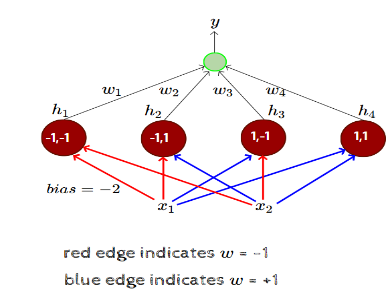>

In [ ]:
def step(x):
    return 1 if x >= 0 else 0

class Neuron:
    def __init__(self, weight, bias):
        self.weights = weight
        self.bias = bias
    def predict(self, x):
        z = np.dot(self.weights, x) + self.bias
        ans = step(z)

        return ans

class MLP_boolean_functions:
    def __init__(self, weight, out_bias):
        self.weight = weight
        self.out_bias = out_bias
        self.hidden = (Neuron([-1, -1], -2), Neuron([-1, 1], -2), Neuron([1, -1], -2), Neuron([1, 1], -2))
    def predict(self, x):
        result = 0
        for i in range(len(self.hidden)):
            result += np.dot(self.hidden[i].predict(x), self.weight[i])
        return step(result + self.out_bias)

# test cases
print("AND")
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

AND = MLP_boolean_functions([0, 0, 0, 1], -0.5)

for i in X:
    print(f"{i}, {AND.predict(i)}")


AND
[0 0], 0
[0 1], 0
[1 0], 0
[1 1], 1


In [ ]:
def step(x):
    return 1 if x >= 0 else 0

class Neuron:
    def __init__(self, weight, bias):
        self.weights = weight
        self.bias = bias
    def predict(self, x):
        z = np.dot(self.weights, x) + self.bias
        return step(z)

class MLP_boolean_functions:
    def __init__(self, weight, out_bias):
        self.weight = weight
        self.out_bias = out_bias
        self.hidden = (
            Neuron([-1, -1], 0.5),   # Detects (0,0)
            Neuron([-1, 1], -0.5),   # Detects (0,1)
            Neuron([1, -1], -0.5),   # Detects (1,0)
            Neuron([1, 1], -1.5)     # Detects (1,1)
        )
    def predict(self, x):
        result = 0
        for i in range(len(self.hidden)):
            result += np.dot(self.hidden[i].predict(x), self.weight[i])
        return step(result + self.out_bias)

# test cases
print("AND")
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

AND = MLP_boolean_functions([0, 0, 0, 1], -0.5)

for i in X:
    print(f"{i}, {AND.predict(i)}")


print("OR")

OR = MLP_boolean_functions([0, 1, 1, 1], -0.5)

for i in X:
    print(f"{i}, {OR.predict(i)}")

AND
[0 0], 0
[0 1], 0
[1 0], 0
[1 1], 1
OR
[0 0], 0
[0 1], 1
[1 0], 1
[1 1], 1


8. **How many Boolean functions can be designed using three binary inputs?**

**![][image1]**  
**Find respective weights w1 to w8) and demonstrate for all the possible boolean functions for three inputs.**

[image1]: <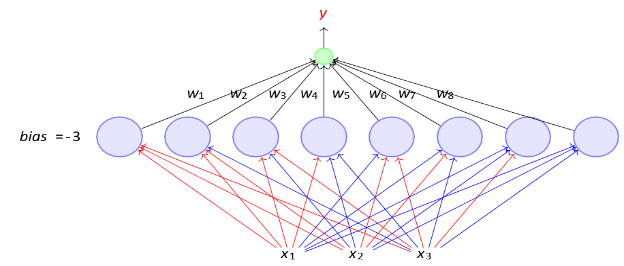>

In [ ]:
def step(x):
    return 1 if x >= 0 else 0

class Perceptron:
    def __init__(self, epochs, lr):
        self.epochs = epochs
        self.lr = lr
    def fit(self, x, y):
        self.weights = np.zeros(x.shape[1])
        self.bias = 0
        for _ in range(self.epochs):
            total_errors = 0
            for i in range(len(x)):
                z = np.dot(self.weights, x[i]) + self.bias
                y_pred = self.predict(x[i])
                error = y[i] - y_pred
                if error != 0:
                    total_errors += 1
                self.weights += self.lr * error * x[i]
                self.bias += self.lr * error
            # print(f"Epoch {_+1} | Total misclassifications: {total_errors}")

            if total_errors == 0:
                break
    def predict(self, inputs):
        total = np.dot(self.weights, inputs) + self.bias
        return step(total)

In [ ]:
# generate all boolean functions
from itertools import product

X = np.array([
    [0, 0, 0],
    [0, 0, 1],
    [0, 1, 0],
    [0, 1, 1],
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1],
])

boolean_functions = list(product([0, 1], repeat=8))
failed_functions = []

for i in range(len(boolean_functions)):
    y = boolean_functions[i]
    percep = Perceptron(50, 0.1)
    percep.fit(X, y)
    failed = False
    for ii in range(len(X)):
        predicted = percep.predict(X[ii])
        actual = y[ii]
        if(actual != predicted):
            failed = True
    if failed:
        failed_functions.append(boolean_functions[i])
print(f"total number of functions: {len(boolean_functions)}")
print(f"number of failed functions: {len(failed_functions)}")

total number of functions: 256
number of failed functions: 152
